# Toy tree in hyperbolic space — first-principles check

Embed a tiny balanced tree (root → 2 orders → 4 families → 8 species) in **2D hyperbolic space**,
placing nodes by **angle = lineage**, **radius = depth**. Then measure **geodesic distances** and
visualise, to verify the claim *distance = taxonomic relatedness*. Uses our own Lorentz primitives.

Edit the placement (angles/radii) in cell 2 and re-run to explore.

In [1]:
import sys
sys.path.insert(0, "/home/daniela/mine/hyperbolic-plankton/src")
import numpy as np, torch
import matplotlib.pyplot as plt
from hyperbolic_plankton import lorentz as L

CURV = 1.0
torch.set_default_dtype(torch.float64)

## 1. Build the tree and place nodes (angle = lineage, radius = depth)

In [2]:
# each node: (name, depth, angle, parent_idx)
nodes = []
def add(name, depth, angle, parent):
    nodes.append((name, depth, angle, parent)); return len(nodes) - 1

RAD = {0: 0.0, 1: 1.0, 2: 2.0, 3: 3.0}   # tangent magnitude per depth (= geodesic radius after exp_map0)

root = add("root", 0, 0.0, -1)
for oi, oa in enumerate([np.pi/2, 3*np.pi/2]):        # 2 orders, opposite sides
    o = add(f"O{oi}", 1, oa, root)
    for fi, df in enumerate([-0.6, 0.6]):             # 2 families per order (+/- 0.6 rad wedge)
        fa = oa + df
        f = add(f"O{oi}F{fi}", 2, fa, o)
        for si, ds in enumerate([-0.3, 0.3]):         # 2 species per family (+/- 0.3 rad)
            add(f"O{oi}F{fi}S{si}", 3, fa + ds, f)

names   = [n[0] for n in nodes]
depths  = np.array([n[1] for n in nodes])
angles  = np.array([n[2] for n in nodes])
parents = [n[3] for n in nodes]
print(f"{len(nodes)} nodes")

15 nodes


## 2. Embed: tangent vector → hyperboloid via exp_map0, then measure radius

In [3]:
tang = torch.tensor([[RAD[d]*np.cos(a), RAD[d]*np.sin(a)] for d, a in zip(depths, angles)])
H = L.exp_map0(tang, CURV)                          # [N,2] hyperboloid space components
radius = L.distance_from_origin(H, CURV).numpy()    # should ~= RAD[depth]

print("node          depth  target_r  measured_r")
for i, nm in enumerate(names):
    print(f"  {nm:12} {int(depths[i]):5d}  {RAD[int(depths[i])]:7.2f}   {float(radius[i]):7.3f}")

node          depth  target_r  measured_r
  root             0     0.00     0.000
  O0               1     1.00     1.000
  O0F0             2     2.00     2.000
  O0F0S0           3     3.00     3.000
  O0F0S1           3     3.00     3.000
  O0F1             2     2.00     2.000
  O0F1S0           3     3.00     3.000
  O0F1S1           3     3.00     3.000
  O1               1     1.00     1.000
  O1F0             2     2.00     2.000
  O1F0S0           3     3.00     3.000
  O1F0S1           3     3.00     3.000
  O1F1             2     2.00     2.000
  O1F1S0           3     3.00     3.000
  O1F1S1           3     3.00     3.000


## 3. The tree-property test: geodesic distance vs shared-lineage depth (LCA)\n\nIf *distance = relatedness*, species sharing a **family** should be closest, sharing only an **order** farther, sharing only the **root** farthest.

In [4]:
D = L.pairwise_dist(H, H, CURV).numpy()

def lca_depth(i, j):
    def anc(k):
        p=[]
        while k!=-1: p.append(k); k=parents[k]
        return p
    shared = set(anc(i)) & set(anc(j))
    return max(int(depths[k]) for k in shared)

species = [i for i,d in enumerate(depths) if d==3]
buckets = {0:[],1:[],2:[]}
for a in range(len(species)):
    for b in range(a+1,len(species)):
        i,j = species[a],species[b]
        buckets[lca_depth(i,j)].append(float(D[i,j]))

lab = {0:"only root (distant clades)",1:"same ORDER",2:"same FAMILY (cousins/siblings)"}
print("species-pair geodesic distance by LCA depth:")
for k in sorted(buckets):
    v=buckets[k]
    if v: print(f"  LCA={k} [{lab[k]:30}] mean {np.mean(v):.3f}  range [{min(v):.3f},{max(v):.3f}]  n={len(v)}")

species-pair geodesic distance by LCA depth:
  LCA=0 [only root (distant clades)    ] mean 5.753  range [5.057,6.000]  n=16
  LCA=1 [same ORDER                    ] mean 4.715  range [3.612,5.515]  n=8
  LCA=2 [same FAMILY (cousins/siblings)] mean 3.612  range [3.612,3.612]  n=4


## 4. Visualise: tree on the Poincaré disk + geodesic distance matrix

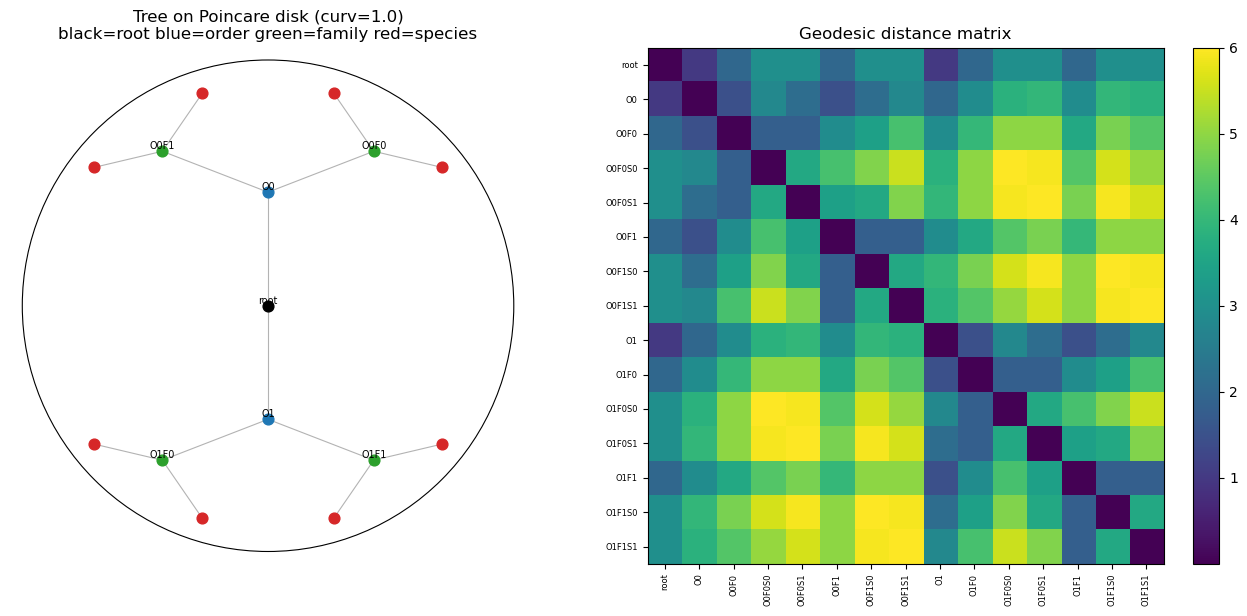

In [5]:
def to_poincare(Hsp, curv):
    t = L.time_component(Hsp, curv)   # already [N,1]
    return (Hsp / (t + 1.0)).numpy()
P = to_poincare(H, CURV)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].add_patch(plt.Circle((0,0),1.0,color="k",fill=False,lw=0.8))
dcol = {0:"k",1:"#1f77b4",2:"#2ca02c",3:"#d62728"}
for i in range(len(names)):
    if parents[i]>=0:
        p=parents[i]
        ax[0].plot([P[i,0],P[p,0]],[P[i,1],P[p,1]],"-",color="0.7",lw=0.8,zorder=1)
for i,nm in enumerate(names):
    ax[0].scatter(P[i,0],P[i,1],c=dcol[depths[i]],s=60,zorder=2)
    if depths[i]<=2: ax[0].annotate(nm,(P[i,0],P[i,1]),fontsize=7,ha="center",va="bottom")
ax[0].set_xlim(-1.05,1.05); ax[0].set_ylim(-1.05,1.05); ax[0].set_aspect("equal"); ax[0].axis("off")
ax[0].set_title(f"Tree on Poincare disk (curv={CURV})\nblack=root blue=order green=family red=species")
im=ax[1].imshow(D,cmap="viridis")
ax[1].set_xticks(range(len(names))); ax[1].set_yticks(range(len(names)))
ax[1].set_xticklabels(names,rotation=90,fontsize=6); ax[1].set_yticklabels(names,fontsize=6)
ax[1].set_title("Geodesic distance matrix"); plt.colorbar(im,ax=ax[1],fraction=0.046)
plt.tight_layout(); plt.show()

---
# 5. Pseudo-images: the highest-fan-out level (species → K images)

Each species gets K pseudo-images. **Species→images is the widest branching** in a real taxonomy
(one species, many photos), and it's where the geometric stress is highest. Two scatter models for
how an image sits relative to its species node — the two CL philosophies we've debated:

- **angular**: images fan *around the species' angle* at ~the species radius → models distance-CL
  "cluster near the species node".
- **radial**: images spread *along the species' radial ray* (slightly beyond it, = more specific)
  → models ATMG "image is a more specific instance; radius=instance, angle=lineage".

Edit `K`, `ANG_SCATTER`, `RAD_SCATTER` and re-run.

In [6]:
K = 8                 # images per species  (raise to test capacity vs fan-out)
ANG_SCATTER = 0.12    # angular scatter (rad) for the 'angular' model
RAD_SCATTER = 0.6     # radial spread for the 'radial' model
rng = np.random.default_rng(0)

species_idx = [i for i,d in enumerate(depths) if d==3]

def make_images(model):
    """Return (tang [M,2] tangent vectors, img_species [M] parent species index)."""
    tv, parent = [], []
    for s in species_idx:
        a0 = angles[s]; r0 = RAD[3]
        for _ in range(K):
            if model == "angular":
                a = a0 + rng.normal(0, ANG_SCATTER); r = r0 + rng.normal(0, 0.05)
            else:  # radial: same angle, spread OUTWARD along the ray (image >= species radius)
                a = a0 + rng.normal(0, 0.02); r = r0 + abs(rng.normal(0, RAD_SCATTER))
            tv.append([r*np.cos(a), r*np.sin(a)]); parent.append(s)
    return torch.tensor(tv), np.array(parent)

imgs = {}
for model in ["angular","radial"]:
    tv, par = make_images(model)
    Himg = L.exp_map0(tv, CURV)
    imgs[model] = dict(H=Himg, parent=par, P=to_poincare(Himg, CURV))
    print(f"{model}: {Himg.shape[0]} pseudo-images ({len(species_idx)} species x {K})")

angular: 64 pseudo-images (8 species x 8)
radial: 64 pseudo-images (8 species x 8)


## 5a. Capacity vs fan-out + relatedness ordering (image↔image distances by shared lineage)

In [7]:
# species prototypes (the species text nodes) for margin/classification
Hsp = H[species_idx]                       # [S,2]
sp_lca = {}  # precompute species-species LCA depth
for a in range(len(species_idx)):
    for b in range(len(species_idx)):
        sp_lca[(a,b)] = lca_depth(species_idx[a], species_idx[b])

for model in ["angular","radial"]:
    Himg, par = imgs[model]["H"], imgs[model]["parent"]
    Dii = L.pairwise_dist(Himg, Himg, CURV).numpy()
    # bucket image-pair distances by the LCA depth of their two species
    sidx = {s:k for k,s in enumerate(species_idx)}
    buck = {3:[],2:[],1:[],0:[]}   # 3 = SAME species
    M = len(par)
    for i in range(M):
        for j in range(i+1,M):
            si, sj = par[i], par[j]
            lca = 3 if si==sj else sp_lca[(sidx[si], sidx[sj])]
            buck[lca].append(Dii[i,j])
    lab={3:"SAME species",2:"same family",1:"same order",0:"distant clade"}
    print(f"\n[{model}] image-image geodesic distance by shared lineage:")
    for k in [3,2,1,0]:
        v=buck[k]
        if v: print(f"   {lab[k]:14}: mean {np.mean(v):.3f}  (n={len(v)})")


[angular] image-image geodesic distance by shared lineage:
   SAME species  : mean 1.153  (n=224)
   same family   : mean 3.551  (n=256)
   same order    : mean 4.736  (n=512)
   distant clade : mean 5.751  (n=1024)

[radial] image-image geodesic distance by shared lineage:
   SAME species  : mean 0.615  (n=224)
   same family   : mean 4.612  (n=256)
   same order    : mean 5.756  (n=512)
   distant clade : mean 6.787  (n=1024)


## 5b. Classification margin: is each image nearest to its OWN species node?

In [9]:
for model in ["angular","radial"]:
    Himg, par = imgs[model]["H"], imgs[model]["parent"]
    Dis = L.pairwise_dist(Himg, Hsp, CURV).numpy()       # [M images, S species nodes]
    sidx = {s:k for k,s in enumerate(species_idx)}
    true = np.array([sidx[p] for p in par])
    pred = Dis.argmin(1)
    acc = (pred==true).mean()
    d_correct = Dis[np.arange(len(par)), true]
    dd = Dis.copy(); dd[np.arange(len(par)), true] = np.inf
    d_wrong = dd.min(1)
    margin = d_wrong - d_correct
    print(f"[{model}] nearest-species-node acc = {acc:.3f}   "
          f"per-image margin mean {margin.mean():+.3f}  frac>0 {(margin>0).mean():.3f}")

[angular] nearest-species-node acc = 1.000   per-image margin mean +2.629  frac>0 1.000
[radial] nearest-species-node acc = 1.000   per-image margin mean +3.501  frac>0 1.000


## 5c. Visualise both scatter models on the disk

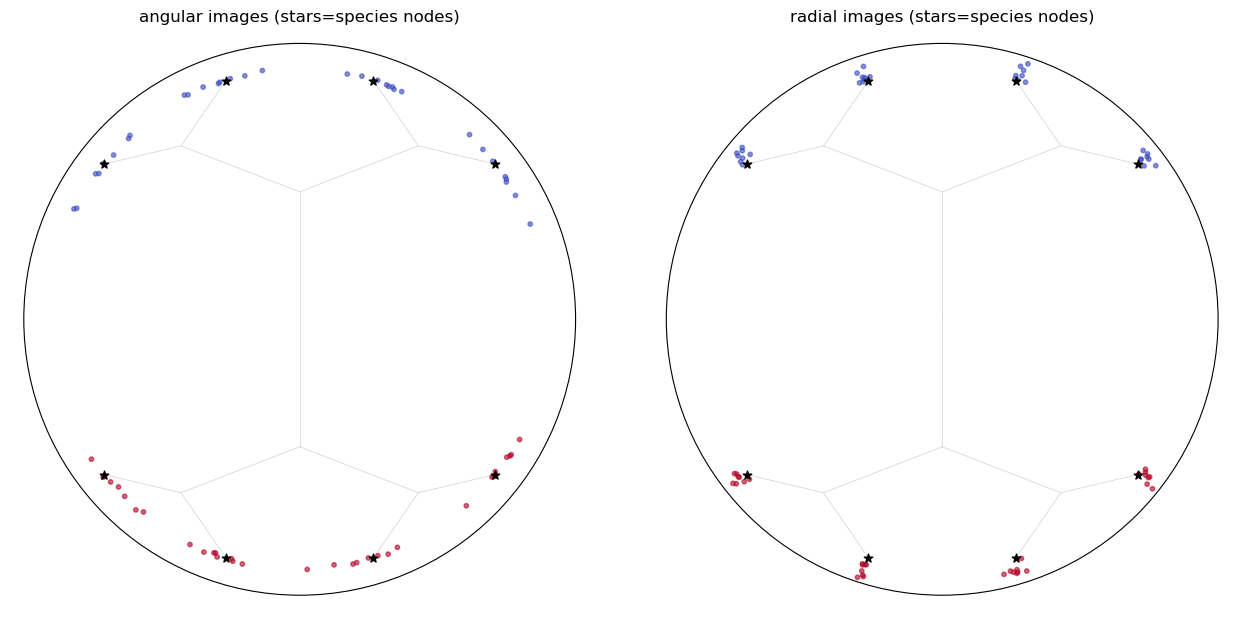

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6.2))
for k, model in enumerate(["angular","radial"]):
    ax[k].add_patch(plt.Circle((0,0),1.0,color="k",fill=False,lw=0.8))
    # tree skeleton (faint)
    for i in range(len(names)):
        if parents[i]>=0:
            p=parents[i]; ax[k].plot([P[i,0],P[p,0]],[P[i,1],P[p,1]],"-",color="0.85",lw=0.6,zorder=1)
    # species nodes
    for s in species_idx:
        ax[k].scatter(P[s,0],P[s,1],c="k",s=40,marker="*",zorder=3)
    # images coloured by ORDER (to see clade separation)
    Pi, par = imgs[model]["P"], imgs[model]["parent"]
    order_of = np.array([int(names[p][1]) for p in par])  # O0/O1
    ax[k].scatter(Pi[:,0],Pi[:,1],c=order_of,cmap="coolwarm",s=10,alpha=0.6,zorder=2)
    ax[k].set_xlim(-1.05,1.05); ax[k].set_ylim(-1.05,1.05); ax[k].set_aspect("equal"); ax[k].axis("off")
    ax[k].set_title(f"{model} images (stars=species nodes)")
plt.tight_layout(); plt.show()

---
# 6. Unseen species: where do angle-CL vs distance-CL place its image?

We verified (cell above) that `oxy_angle(text, image) ≈ 0` requires the image to lie on the text's
**ray from the hyperbolic origin, at radius ≥ the text's** (outward = more specific). So:

- **angle-CL** drives the image onto the lineage ray, OUTWARD of the text → "more specific instance
  of this lineage", radius free.
- **distance-CL** drives the image to COINCIDE with the text node (minimise geodesic distance) →
  pinned at the text's exact radius+angle.

Put an **unseen species** between two seen families (a new genus the tree didn't have), place its
text at the right lineage angle, and show where each loss would put its image — and whether that
image stays nearer the UNSEEN text than to the nearest SEEN species node.

In [11]:
# unseen species: a new lineage in order O0, angle BETWEEN family O0F0 and O0F1, at species radius
o0_angle = np.pi/2                       # order O0 direction
unseen_angle = o0_angle + 0.0            # right between its two families (a novel genus/species)
unseen_text = L.exp_map0(torch.tensor([[RAD[3]*np.cos(unseen_angle), RAD[3]*np.sin(unseen_angle)]]), CURV)

# where each loss places an IMAGE of this unseen species:
#  - angle-CL: same angle, OUTWARD (radius > text). pick radius 4 (more specific).
img_angleCL = L.exp_map0(torch.tensor([[4.0*np.cos(unseen_angle), 4.0*np.sin(unseen_angle)]]), CURV)
#  - distance-CL: coincide with the text node (radius 3, same angle).
img_distCL  = L.exp_map0(torch.tensor([[RAD[3]*np.cos(unseen_angle), RAD[3]*np.sin(unseen_angle)]]), CURV)

# classify each image against ALL species nodes (the 8 seen) PLUS the unseen text as a candidate
cand_H = torch.cat([Hsp, unseen_text], dim=0)          # [9, 2]
cand_names = [names[s] for s in species_idx] + ["UNSEEN"]
for label, img in [("angle-CL image", img_angleCL), ("distance-CL image", img_distCL)]:
    d = L.pairwise_dist(img, cand_H, CURV).numpy()[0]
    order = np.argsort(d)
    nearest = cand_names[order[0]]
    print(f"{label}: nearest candidate = {nearest}  "
          f"(d_unseen={d[-1]:.3f}, d_nearest_seen={d[order][:1] if nearest!='UNSEEN' else d[np.argsort(d)[1]]:.3f})")
    print(f"    ranking: " + ", ".join(f"{cand_names[i]}({d[i]:.2f})" for i in order[:3]))

angle-CL image: nearest candidate = UNSEEN  (d_unseen=1.000, d_nearest_seen=3.313)
    ranking: UNSEEN(1.00), O0F0S1(3.31), O0F1S0(3.31)
distance-CL image: nearest candidate = UNSEEN  (d_unseen=0.000, d_nearest_seen=2.386)
    ranking: UNSEEN(0.00), O0F0S1(2.39), O0F1S0(2.39)


## 6b. Visualise: unseen text + both image placements vs the seen tree

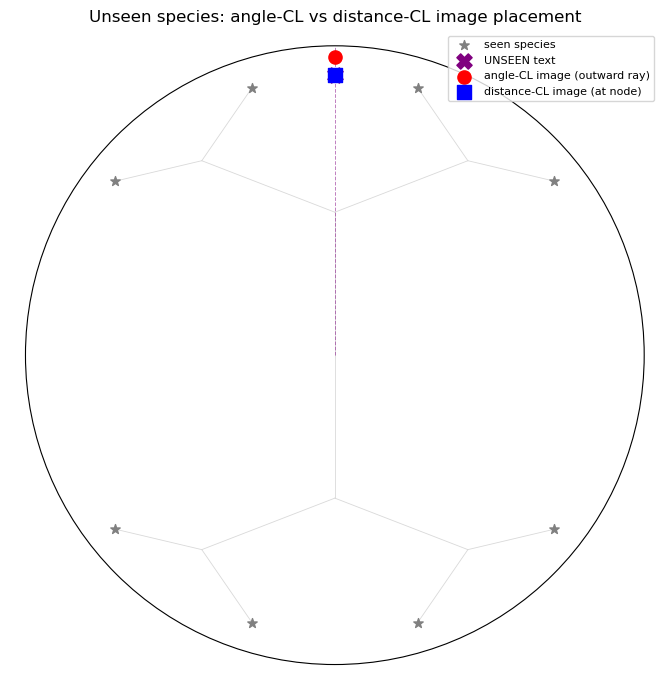

In [12]:
fig, ax = plt.subplots(figsize=(7,7))
ax.add_patch(plt.Circle((0,0),1.0,color="k",fill=False,lw=0.8))
for i in range(len(names)):
    if parents[i]>=0:
        p=parents[i]; ax.plot([P[i,0],P[p,0]],[P[i,1],P[p,1]],"-",color="0.85",lw=0.6,zorder=1)
for s in species_idx:
    ax.scatter(P[s,0],P[s,1],c="0.5",s=50,marker="*",zorder=2,label="seen species" if s==species_idx[0] else None)
def pp(x): 
    q=to_poincare(x,CURV)[0]; return q
ut=pp(unseen_text); ia=pp(img_angleCL); idd=pp(img_distCL)
ax.scatter(*ut,c="purple",s=120,marker="X",zorder=4,label="UNSEEN text")
ax.scatter(*ia,c="red",s=90,marker="o",zorder=4,label="angle-CL image (outward ray)")
ax.scatter(*idd,c="blue",s=90,marker="s",zorder=4,label="distance-CL image (at node)")
# draw the lineage ray from origin through the unseen text
ax.plot([0,pp(L.exp_map0(torch.tensor([[6*np.cos(unseen_angle),6*np.sin(unseen_angle)]]),CURV))[0]],
        [0,pp(L.exp_map0(torch.tensor([[6*np.cos(unseen_angle),6*np.sin(unseen_angle)]]),CURV))[1]],
        "--",color="purple",lw=0.7,alpha=0.5,zorder=1)
ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05); ax.set_aspect("equal"); ax.axis("off")
ax.legend(fontsize=8,loc="upper right"); ax.set_title("Unseen species: angle-CL vs distance-CL image placement")
plt.tight_layout(); plt.show()